# Trans Effects Comparison

Cross-dataset comparison of trans-regulatory effects from calibrated results:
- Positive control # of cells barplots
- Positive control # of DEGs barplots  
- Positive control Venn diagrams of DEGs + Jaccard
- Pairwise Jaccard similarity distributions
- Split by target type (positive control, TF targeting)
- Pathway enrichment comparison

**Input:** Calibrated trans results + pathway results from `calibration/` dirs  
**Output:** Combined tables and comparison plots

In [1]:
import os
import sys
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
# Project root
PROJECT_ROOT = Path("/cellar/users/aklie/data/datasets/tf_perturb_seq")

sys.path.append(str(PROJECT_ROOT / "config"))
from loader import load_colors

dataset_colors = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_colors")
dataset_order = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_order")

In [3]:
# Paths
RUN_LABEL = "cleanser_unified"
FDR_THRESHOLD = 0.10

BASE_DIR = PROJECT_ROOT / "datasets" / "technology-benchmark_WTC11_TF-Perturb-seq"
OUTPUT_DIR = BASE_DIR / "results" / "cross_tech_comparison" / RUN_LABEL / "inference"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATASETS_ROOT = PROJECT_ROOT / "datasets"

DATASETS = [
    "Hon_WTC11-benchmark_TF-Perturb-seq",
    "Huangfu_WTC11-benchmark_TF-Perturb-seq",
    "Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3",
    "Gersbach_WTC11-benchmark_TF-Perturb-seq_HTv2",
    "Engreitz_WTC11-benchmark_TF-Perturb-seq",
]

SUFFIX = "_WTC11-benchmark_TF-Perturb-seq"
def short_name(ds):
    return ds.replace(SUFFIX, "").replace("_", " ")

print(f"Run label: {RUN_LABEL}")
print(f"FDR threshold: {FDR_THRESHOLD}")
print(f"Output directory: {OUTPUT_DIR}")

Run label: cleanser_unified
FDR threshold: 0.1
Output directory: /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified/inference


In [4]:
# Load trans results (excluding cis) and pathway results
trans_results = {}
pathway_results = {}

for ds in DATASETS:
    cal_dir = DATASETS_ROOT / ds / "runs" / RUN_LABEL / "calibration"
    
    trans_path = cal_dir / f"{ds}_calibrated_trans_results.tsv"
    pw_path = cal_dir / f"{ds}_calibrated_pathway_results.tsv"
    
    if trans_path.exists():
        trans_results[ds] = pd.read_csv(trans_path, sep="\t", low_memory=False)
        trans_results[ds]["dataset"] = ds
        print(f"  {short_name(ds)}: {len(trans_results[ds]):,} trans tests")
    else:
        print(f"  {short_name(ds)}: MISSING trans results")
    
    if pw_path.exists():
        pathway_results[ds] = pd.read_csv(pw_path, sep="\t")
        pathway_results[ds]["dataset"] = ds
        print(f"    → {len(pathway_results[ds]):,} pathway enrichments")

print(f"\nLoaded {len(trans_results)} trans, {len(pathway_results)} pathway datasets")

  Hon: 692,004 trans tests
    → 36,627 pathway enrichments
  Huangfu: 620,536 trans tests
    → 54,114 pathway enrichments
  Gersbach GEM-Xv3: 1,008,385 trans tests
    → 37,923 pathway enrichments
  Gersbach HTv2: 947,412 trans tests
    → 34,002 pathway enrichments
  Engreitz: 362,386 trans tests
    → 29,747 pathway enrichments

Loaded 5 trans, 5 pathway datasets


## Per-Element DEG Counts

Number of cells and significant trans DEGs per element, split by target type.

In [ ]:
# Compute per-element summary: n_cells, n_degs, element_label
element_summaries = []

for ds in dataset_order:
    if ds not in trans_results:
        continue
    df = trans_results[ds]
    targeting = df[df["element_label"].str.lower().str.replace("-", "_") != "non_targeting"]
    
    sig = targeting[targeting["empirical_pval_adj"] < FDR_THRESHOLD]
    
    # Per-element DEG counts
    deg_counts = sig.groupby("element_id").agg(
        n_degs=("tested_gene_id", "count"),
        n_up=("log2fc", lambda x: (x > 0).sum()),
        n_down=("log2fc", lambda x: (x < 0).sum()),
    ).reset_index()
    
    # Merge with element metadata (n_cells, label, symbol)
    meta = targeting.drop_duplicates("element_id")[["element_id", "element_symbol", "element_label", "n_cells"]]
    deg_counts = meta.merge(deg_counts, on="element_id", how="left").fillna({"n_degs": 0, "n_up": 0, "n_down": 0})
    deg_counts["dataset"] = ds
    element_summaries.append(deg_counts)

elem_df = pd.concat(element_summaries, ignore_index=True)
elem_df["dataset"] = pd.Categorical(elem_df["dataset"], categories=dataset_order, ordered=True)
elem_df["lab"] = elem_df["dataset"].astype(str).apply(short_name)

# Save
elem_df.to_csv(OUTPUT_DIR / "per_element_deg_summary.tsv", sep="\t", index=False)
print(f"Per-element summary: {len(elem_df)} elements across {elem_df['dataset'].nunique()} datasets")
elem_df.head()

ValueError: The palette dictionary is missing keys: {'Gersbach_HTv2', 'Gersbach_GEM-Xv3'}

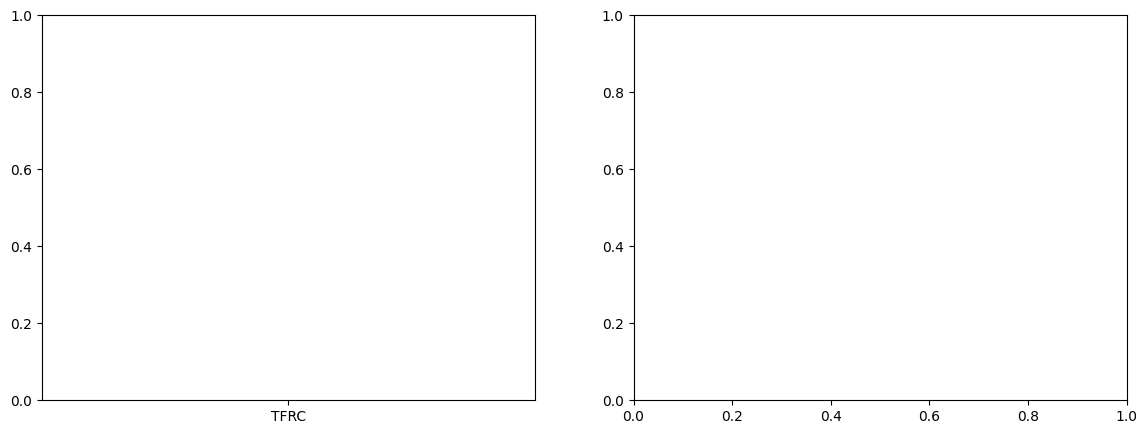

In [6]:
# Positive control barplots: n_cells and n_degs
pos_ctrl = elem_df[elem_df["element_label"] == "positive control"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# n_cells
ax = axes[0]
sns.barplot(data=pos_ctrl, x="element_symbol", y="n_cells", hue="lab", 
            palette={short_name(ds): dataset_colors[ds] for ds in dataset_order}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("# Cells")
ax.set_title("Positive Control: Cells per Element")
ax.legend(title="Dataset", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax.tick_params(axis="x", rotation=45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# n_degs
ax = axes[1]
sns.barplot(data=pos_ctrl, x="element_symbol", y="n_degs", hue="lab",
            palette={short_name(ds): dataset_colors[ds] for ds in dataset_order}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel(f"# DEGs (FDR < {FDR_THRESHOLD})")
ax.set_title("Positive Control: Trans DEGs per Element")
ax.legend(title="Dataset", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax.tick_params(axis="x", rotation=45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "posctrl_cells_and_degs.pdf", dpi=300, bbox_inches="tight")
plt.show()

## DEG Overlap: Venn Diagrams and Jaccard Similarity

For positive controls, compare which DEGs are shared across datasets.

In [ ]:
# Build DEG sets per (element_symbol, dataset) for positive controls
# Then compute pairwise Jaccard across datasets for each element

def jaccard(a, b):
    if len(a) == 0 and len(b) == 0:
        return np.nan
    return len(a & b) / len(a | b)

# Get sig DEG gene sets per element per dataset
deg_sets = {}
for ds in dataset_order:
    if ds not in trans_results:
        continue
    df = trans_results[ds]
    sig = df[(df["empirical_pval_adj"] < FDR_THRESHOLD) & (df["element_label"] == "positive control")]
    for elem, grp in sig.groupby("element_symbol"):
        deg_sets[(elem, ds)] = set(grp["tested_gene_symbol"].dropna())

# Compute pairwise Jaccard for each element
elements = sorted(set(e for e, _ in deg_sets.keys()))
ds_pairs = list(combinations([ds for ds in dataset_order if ds in trans_results], 2))

jaccard_rows = []
for elem in elements:
    for ds1, ds2 in ds_pairs:
        s1 = deg_sets.get((elem, ds1), set())
        s2 = deg_sets.get((elem, ds2), set())
        if len(s1) == 0 and len(s2) == 0:
            continue
        jaccard_rows.append({
            "element": elem,
            "dataset_1": short_name(ds1),
            "dataset_2": short_name(ds2),
            "jaccard": jaccard(s1, s2),
            "n_shared": len(s1 & s2),
            "n_union": len(s1 | s2),
            "n_ds1": len(s1),
            "n_ds2": len(s2),
        })

jaccard_df = pd.DataFrame(jaccard_rows)
jaccard_df.to_csv(OUTPUT_DIR / "posctrl_deg_jaccard.tsv", sep="\t", index=False)
print(f"Pairwise Jaccard: {len(jaccard_df)} comparisons")
jaccard_df.head(10)

In [ ]:
# Jaccard heatmap per positive control element
for elem in elements:
    elem_j = jaccard_df[jaccard_df["element"] == elem]
    if elem_j.empty:
        continue
    
    # Build symmetric matrix
    labs = sorted(set(elem_j["dataset_1"]) | set(elem_j["dataset_2"]))
    mat = pd.DataFrame(1.0, index=labs, columns=labs)
    for _, row in elem_j.iterrows():
        mat.loc[row["dataset_1"], row["dataset_2"]] = row["jaccard"]
        mat.loc[row["dataset_2"], row["dataset_1"]] = row["jaccard"]
    
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=ax,
                square=True, linewidths=0.5)
    ax.set_title(f"{elem} — DEG Jaccard Similarity")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"jaccard_heatmap_{elem}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

## Pairwise Jaccard Distributions

Distribution of Jaccard similarities across all TF-targeting elements (not just positive controls).

In [ ]:
# Compute Jaccard for ALL targeting elements (not just positive controls)
all_deg_sets = {}
for ds in dataset_order:
    if ds not in trans_results:
        continue
    df = trans_results[ds]
    sig = df[df["empirical_pval_adj"] < FDR_THRESHOLD]
    for elem, grp in sig.groupby("element_symbol"):
        all_deg_sets[(elem, ds)] = set(grp["tested_gene_symbol"].dropna())

all_elements = sorted(set(e for e, _ in all_deg_sets.keys()))

all_jaccard_rows = []
for ds1, ds2 in ds_pairs:
    pair_jaccards = []
    for elem in all_elements:
        s1 = all_deg_sets.get((elem, ds1), set())
        s2 = all_deg_sets.get((elem, ds2), set())
        if len(s1) == 0 and len(s2) == 0:
            continue
        j = jaccard(s1, s2)
        pair_jaccards.append(j)
        all_jaccard_rows.append({
            "element": elem,
            "pair": f"{short_name(ds1)} vs {short_name(ds2)}",
            "jaccard": j,
        })

all_jaccard_df = pd.DataFrame(all_jaccard_rows)

# Violin plot of Jaccard distributions per dataset pair
fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(data=all_jaccard_df, x="pair", y="jaccard", inner="quartile", cut=0, ax=ax)
ax.set_ylabel("Jaccard Similarity")
ax.set_xlabel("")
ax.set_title(f"Pairwise DEG Overlap (FDR < {FDR_THRESHOLD})")
ax.tick_params(axis="x", rotation=45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "jaccard_pairwise_distributions.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Pathway Enrichment Comparison

Compare significant pathway enrichments across datasets.

In [ ]:
# Combine pathway results
if pathway_results:
    pw_combined = pd.concat(pathway_results.values(), ignore_index=True)
    pw_combined["dataset"] = pd.Categorical(pw_combined["dataset"], categories=dataset_order, ordered=True)
    pw_combined["lab"] = pw_combined["dataset"].astype(str).apply(short_name)
    
    # Save
    pw_combined.to_csv(OUTPUT_DIR / "combined_pathway_results.tsv", sep="\t", index=False)
    
    # Significant pathways per element per dataset
    pw_sig = pw_combined[pw_combined["pvalue_adj"] < 0.05]
    print(f"Total pathway enrichments: {len(pw_combined):,}")
    print(f"Significant (FDR < 0.05): {len(pw_sig):,}")
    print(f"Unique pathways: {pw_sig['pathway_id'].nunique()}")
    print(f"Elements with sig pathways: {pw_sig['element_id'].nunique()}")
else:
    print("No pathway results available")

In [ ]:
# Top pathways: most frequently enriched across datasets
if pathway_results:
    # Count how many (element, dataset) pairs each pathway is significant in
    pw_freq = pw_sig.groupby("pathway_name").agg(
        n_element_dataset_pairs=("element_id", "count"),
        n_datasets=("dataset", "nunique"),
        n_elements=("element_symbol", "nunique"),
        mean_fold_enrichment=("fold_enrichment", "mean"),
    ).sort_values("n_element_dataset_pairs", ascending=False)
    
    # Top 20 most frequent pathways
    top_pw = pw_freq.head(20)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(range(len(top_pw)), top_pw["n_element_dataset_pairs"], color="steelblue", edgecolor="black", linewidth=0.5)
    ax.set_yticks(range(len(top_pw)))
    ax.set_yticklabels([name.split("/")[-1] if "/" in name else name for name in top_pw.index], fontsize=8)
    ax.set_xlabel("# Element-Dataset Pairs")
    ax.set_title("Most Frequently Enriched Pathways (FDR < 0.05)")
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Annotate with n_datasets
    for i, (_, row) in enumerate(top_pw.iterrows()):
        ax.text(row["n_element_dataset_pairs"] + 0.3, i, f"{int(row['n_datasets'])} ds", va="center", fontsize=8)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "top_pathways_frequency.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    
    pw_freq.to_csv(OUTPUT_DIR / "pathway_frequency_summary.tsv", sep="\t")

---

# DONE!